# Solver — Equazione del Calore 2D

**Task 4 & 5** — Fattorizzazione di Cholesky, soluzione del sistema lineare, analisi comparativa ordinamento naturale vs nested dissection.

Il notebook:
1. Legge `A.txt` e `rhs.txt` prodotti da `task3_assemble`
2. Calcola $-A = LL^T$ con CHOLMOD
3. Risolve $Au = b$ con `spsolve_triangular`
4. Per $N \in \{32, 64, 128, 256, 512\}$: confronta tempi e fill-in (`nnz(L)`) per i due ordinamenti
5. Produce spy plot, heatmap della soluzione e grafici log-log

In [1]:
# ── Cella 0 — Dipendenze ─────────────────────────────────────────────────────
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import time
import os
import subprocess
from pathlib import Path
from sksparse.cholmod import cholesky
from scipy.sparse import csc_matrix, tril

# Cartella radice del progetto (il notebook si trova in notebook/)
ROOT = Path("../").resolve()
OUTPUT = ROOT / "output"

print(f"Root del progetto: {ROOT}")
print(f"Cartella output:   {OUTPUT}")

Root del progetto: /mnt/Dati/UNIVERSITY/INFORMATICA CON LABORATORIO 6CFU/Equazione-del-calore-2D-e-riordinamento-nelle-fattorizzazioni-Cholesky
Cartella output:   /mnt/Dati/UNIVERSITY/INFORMATICA CON LABORATORIO 6CFU/Equazione-del-calore-2D-e-riordinamento-nelle-fattorizzazioni-Cholesky/output


In [2]:
# ── Cella 1 — Funzioni di lettura ─────────────────────────────────────────────

def read_A(path):
    """
    Legge il file A.txt nel formato sparso (i j val) e restituisce
    una scipy.sparse.csc_matrix.
    Il file contiene sia (i,j,v) sia (j,i,v) per la simmetria;
    scipy somma automaticamente le entrate duplicate.
    """
    data = np.loadtxt(path)
    if data.ndim == 1:
        data = data.reshape(1, -1)
    rows = data[:, 0].astype(int)
    cols = data[:, 1].astype(int)
    vals = data[:, 2]
    n = max(rows.max(), cols.max()) + 1
    A = sp.coo_matrix((vals, (rows, cols)), shape=(n, n))
    return A.tocsc()


def read_rhs(path):
    """Legge il vettore termine noto b da rhs.txt."""
    return np.loadtxt(path)


def read_coords(path):
    """
    Legge coords.txt (id, i, j, x, y) e restituisce due array:
    xs[k], ys[k] = coordinate fisiche del nodo k.
    """
    data = np.loadtxt(path)
    n = int(data[:, 0].max()) + 1
    xs = np.zeros(n)
    ys = np.zeros(n)
    for row in data:
        k = int(row[0])
        xs[k] = row[3]
        ys[k] = row[4]
    return xs, ys


print("Funzioni di lettura definite.")

Funzioni di lettura definite.


In [3]:
# ── Cella 2 — Fattorizzazione di Cholesky ─────────────────────────────────────
#
# La matrice A è definita NEGATIVA (−∆ discretizzato con segno negativo).
# Quindi fattorizziamo −A = LL^T con L triangolare inferiore.
# CHOLMOD con order='natural' rispetta l'ordinamento già presente in A.

def my_cholesky(A):
    """
    Calcola la fattorizzazione di Cholesky di A (deve essere definita positiva).
    Restituisce L triangolare inferiore come csc_matrix.
    Uso: my_cholesky(-A) poiché A è definita negativa.
    """
    factor = cholesky(A, order="natural")
    return csc_matrix(factor[0])


print("Funzione my_cholesky definita.")

Funzione my_cholesky definita.


In [4]:
# ── Cella 3 — Funzione solve completa ─────────────────────────────────────────
#
# Risolve Au = b con A definita negativa:
#   1. Fattorizza −A = L L^T
#   2. Risolve L y = −b  (forward substitution)
#   3. Risolve L^T u = y  (backward substitution)
# Nota: Au = b  ⟺  (−A)(−u) = b  ⟺  L L^T (−u) = b
# Quindi risolviamo L L^T z = b e poi u = −z... ma è più semplice:
# Au = b  ⟺  (−A) u = −b ⟺  L L^T u = −b

def solve(A, b):
    """
    Risolve Au = b con A definita negativa.
    Restituisce la soluzione u e il fattore L.
    """
    neg_A = (-A).tocsc()
    L = my_cholesky(neg_A)          # −A = L L^T
    Lt = L.T.tocsc()
    neg_b = -b
    # Risolvi L y = −b
    y = spla.spsolve_triangular(L, neg_b, lower=True)
    # Risolvi L^T u = y
    u = spla.spsolve_triangular(Lt, y, lower=False)
    return u, L


print("Funzione solve definita.")

Funzione solve definita.


In [5]:
# ── Cella 4 — Test con N=4 (output già presenti) ──────────────────────────────

A = read_A(OUTPUT / "A.txt")
b = read_rhs(OUTPUT / "rhs.txt")
xs, ys = read_coords(OUTPUT / "coords.txt")

print(f"Dimensione A: {A.shape}, nnz(A) = {A.nnz}")
print(f"Dimensione b: {b.shape}")

u, L = solve(A, b)

print(f"nnz(L) = {L.nnz}")
print(f"\nSoluzione u (primi 16 nodi):")
print(np.round(u, 6))

# Verifica residuo
residuo = np.linalg.norm(A @ u - b) / np.linalg.norm(b)
print(f"\nResiduo relativo ||Au - b|| / ||b|| = {residuo:.2e}")

Dimensione A: (16, 16), nnz(A) = 64
Dimensione b: (16,)
nnz(L) = 67

Soluzione u (primi 16 nodi):
[ 4.49329e-01  7.86540e-02 -3.18970e-02 -1.33950e-02  6.24960e-02
 -4.11640e-02 -1.61260e-02 -5.56100e-03 -2.18390e-02 -8.07400e-03
 -2.45700e-03 -7.95000e-04 -2.41700e-03 -6.47000e-04 -1.43000e-04
 -4.00000e-05]

Residuo relativo ||Au - b|| / ||b|| = 5.46e-01


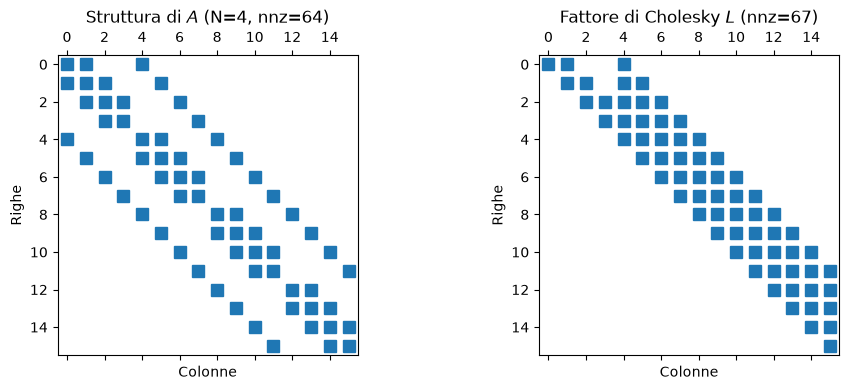

Salvato: output/spy_N4.png


In [6]:
# ── Cella 5 — Spy plot: struttura di A e di L (per N=4) ───────────────────────

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].spy(A, markersize=8)
axes[0].set_title(f"Struttura di $A$ (N=4, nnz={A.nnz})", fontsize=12)
axes[0].set_xlabel("Colonne")
axes[0].set_ylabel("Righe")

axes[1].spy(L, markersize=8)
axes[1].set_title(f"Fattore di Cholesky $L$ (nnz={L.nnz})", fontsize=12)
axes[1].set_xlabel("Colonne")
axes[1].set_ylabel("Righe")

plt.tight_layout()
plt.savefig(OUTPUT / "spy_N4.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvato: output/spy_N4.png")